### Assignment-03

- Using the provided ```U-Net``` training notebook as a reference, develop and train a ```DeepLabv3+``` model on the sample dataset available in the ```data``` folder (accessible through the provided Google Drive shortcut).

- For model evaluation, use the same test image that was previously used to evaluate the U-Net model. Save and upload the output image generated by your trained DeepLabv3+ model to the ```data/output``` folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.models.segmentation as models



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cpu


In [ ]:
BASE = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE"


IMG_DIR  = BASE + "/train2017"
MASK_DIR = BASE + "/mask_train2017"
TEST_DIR = BASE + "/test2017"
OUT_DIR  = BASE + "/output"

TEST_IMAGE_PATH = TEST_DIR + "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/test2017"

os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:
import os

train_image_dir = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/train2017"
train_mask_dir  = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/mask_train2017"

# Collect image base IDs (without .jpg)
image_ids = set()
for f in os.listdir(train_image_dir):
    if f.endswith(".jpg"):
        image_ids.add(f.replace(".jpg", ""))

# Collect mask base IDs (remove _mask.png)
mask_ids = set()
for f in os.listdir(train_mask_dir):
    if f.endswith("_mask.png"):
        mask_ids.add(f.replace("_mask.png", ""))

# Find intersection
common_ids = image_ids.intersection(mask_ids)

print("Total images:", len(image_ids))
print("Total masks:", len(mask_ids))
print("Matching image-mask pairs:", len(common_ids))

# Show few examples if they exist
print("\nSample matching IDs:")
print(list(common_ids)[:10])


Total images: 11827
Total masks: 38103
Matching image-mask pairs: 3768

Sample matching IDs:
['000000009007', '000000132652', '000000157554', '000000117046', '000000098925', '000000067307', '000000024396', '000000050179', '000000120176', '000000005259']


In [ ]:
image_ids = {f.replace(".jpg","") for f in os.listdir(IMG_DIR) if f.endswith(".jpg")}
mask_ids  = {f.replace("_mask.png","") for f in os.listdir(MASK_DIR) if f.endswith("_mask.png")}

matched_ids = sorted(list(image_ids & mask_ids))
print("Matched pairs:", len(matched_ids))


Matched pairs: 3768


In [ ]:
from PIL import Image
train_images = []
train_masks  = []

for img_id in matched_ids[:50]:
    img_path  = os.path.join(IMG_DIR, img_id + ".jpg")
    mask_path = os.path.join(MASK_DIR, img_id + "_mask.png")

    image = Image.open(img_path).convert("RGB").resize((512,512))
    mask  = Image.open(mask_path).resize((512,512))

    image = np.array(image) / 255.0
    mask  = np.array(mask)

    mask[mask > 0] = 1

    image = torch.tensor(image, dtype=torch.float32).permute(2,0,1)
    mask  = torch.tensor(mask, dtype=torch.long)

    train_images.append(image)
    train_masks.append(mask)

print("Training samples loaded:", len(train_images))

Training samples loaded: 50


In [ ]:
model = models.deeplabv3_resnet50(pretrained=True)
model.classifier[4] = torch.nn.Conv2d(256, 2, kernel_size=1)
model = model.to(device)


In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
print(os.listdir(TEST_DIR))


['000000436731.jpg', '000000436087.jpg', '000000436328.jpg', '000000437334.jpg', '000000436181.jpg', '000000437438.jpg', '000000438826.jpg', '000000438812.jpg', '000000437746.jpg', '000000438574.jpg', '000000438230.jpg', '000000438007.jpg', '000000438356.jpg', '000000439417.jpg', '000000439454.jpg', '000000440402.jpg', '000000440323.jpg', '000000440800.jpg', '000000440242.jpg', '000000439953.jpg', '000000440757.jpg', '000000439620.jpg', '000000442115.jpg', '000000442013.jpg', '000000441809.jpg', '000000441821.jpg', '000000441157.jpg', '000000441495.jpg', '000000441740.jpg', '000000441925.jpg', '000000441279.jpg', '000000442212.jpg', '000000441997.jpg', '000000441191.jpg', '000000443897.jpg', '000000442825.jpg', '000000443171.jpg', '000000442629.jpg', '000000443409.jpg', '000000442766.jpg', '000000443267.jpg', '000000443468.jpg', '000000443998.jpg', '000000442930.jpg', '000000443622.jpg', '000000445407.jpg', '000000444178.jpg', '000000445065.jpg', '000000444938.jpg', '000000444427.jpg',

In [ ]:
test_image_path = os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0])

test_image = Image.open(test_image_path).convert("RGB").resize((512, 512))
test_np = np.array(test_image) / 255.0

test_tensor = torch.tensor(test_np, dtype=torch.float32).permute(2, 0, 1)
test_tensor = test_tensor.unsqueeze(0).to(device)

In [ ]:
model.eval()
with torch.no_grad():
    output = model(test_tensor)["out"]
    prediction = torch.argmax(output, dim=1).squeeze().cpu().numpy()

save_path = os.path.join(OUT_DIR, "deeplabv3_output.png")
plt.imsave(save_path, prediction, cmap="gray")

print("Saved output:", save_path)

Saved output: /content/drive/MyDrive/AI_Vision_Extract_Nov25/COCO2017_SAMPLE/output/deeplabv3_output.png


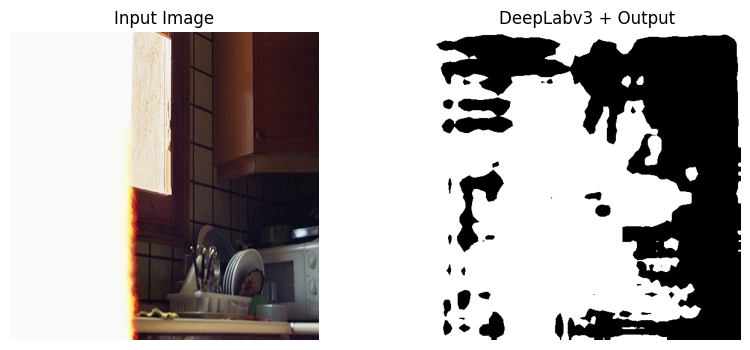

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(test_image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("DeepLabv3 + Output")
plt.imshow(prediction, cmap="gray")
plt.axis("off")

plt.show()